<a href="https://colab.research.google.com/github/Jhairg9/CI345/blob/main/Copy_of_Lab8_KNN_Movie_by_JhairMoralesGonzalez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8 - knn classification for Video data

## Date

### Name: Jhair Morales Gonzalez


In [138]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

#Step 1 : Loading and Analyze Data

In [139]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML/data/Video_Store.csv'

original_vtable = pd.read_csv(video_store_file)
original_vtable.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [140]:
vtable = orginal_vtable.head(3)
df = vtable
print(df.shape)
print('---')
print(df.columns)

(3, 8)
---
Index(['Cust ID', 'Gender', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Genre',
       'Like'],
      dtype='object')


In [141]:
vtable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      3 non-null      int64  
 1   Gender       3 non-null      int64  
 2   Income       3 non-null      int64  
 3   Age          3 non-null      int64  
 4   Rentals      3 non-null      int64  
 5   AvgPerVisit  3 non-null      float64
 6   Genre        3 non-null      int64  
 7   Like         3 non-null      int64  
dtypes: float64(1), int64(7)
memory usage: 324.0 bytes


In [142]:
vtable.shape

(3, 8)

In [143]:
vtable.dtypes

,0
Cust ID,int64
Gender,int64
Income,int64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,int64
Like,int64


In [144]:
df = vtable
df.isnull().sum()

,0
Cust ID,0
Gender,0
Income,0
Age,0
Rentals,0
AvgPerVisit,0
Genre,0
Like,0


In [145]:
vtable['Income'] = vtable['Income'].astype(float)
vtable.dtypes

/tmp/ipykernel_6847/3805015407.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vtable['Income'] = vtable['Income'].astype(float)


,0
Cust ID,int64
Gender,int64
Income,float64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,int64
Like,int64


In [146]:
print(df.Income.describe())
print('------------------------')
#print(df['Income'].describe())
print(df[ ['Income','Age','Rentals']].describe())

count        3.000000
mean     43666.666667
std      11060.440015
min      32000.000000
25%      38500.000000
50%      45000.000000
75%      49500.000000
max      54000.000000
Name: Income, dtype: float64
------------------------
             Income        Age    Rentals
count      3.000000   3.000000   3.000000
mean   43666.666667  26.000000  28.666667
std    11060.440015   6.557439  15.275252
min    32000.000000  20.000000  12.000000
25%    38500.000000  22.500000  22.000000
50%    45000.000000  25.000000  32.000000
75%    49500.000000  29.000000  37.000000
max    54000.000000  33.000000  42.000000


In [147]:
df = orginal_vtable
df.head(3)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0
2,3,0,32000,20,42,1.6,1,0


# Step 2 : Data Visualization

Genre
2    20
0    18
1    12
Name: count, dtype: int64


<Axes: title={'center': 'Numbers in Each Genre'}, xlabel='Genre'>

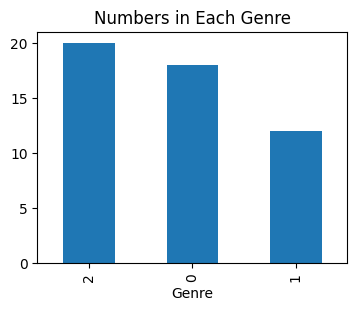

In [156]:
res = df.Genre.value_counts()
print(res)
res.plot(kind='bar',title='Numbers in Each Genre', figsize=(4, 3) )

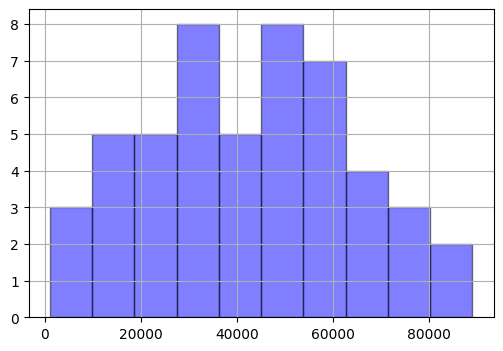

In [157]:
df = orginal_vtable
res = df["Income"]
#res.plot(kind="hist", bins=5)
res.hist(color='blue',alpha=0.5, edgecolor = "black",figsize=(6, 4));

<Axes: title={'center': 'Percentage in Each Genre'}, ylabel='count'>

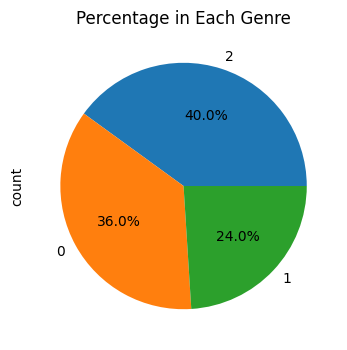

In [158]:
res = df['Genre'].value_counts()

res.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Percentage in Each Genre',
    figsize = (6, 4)
   )

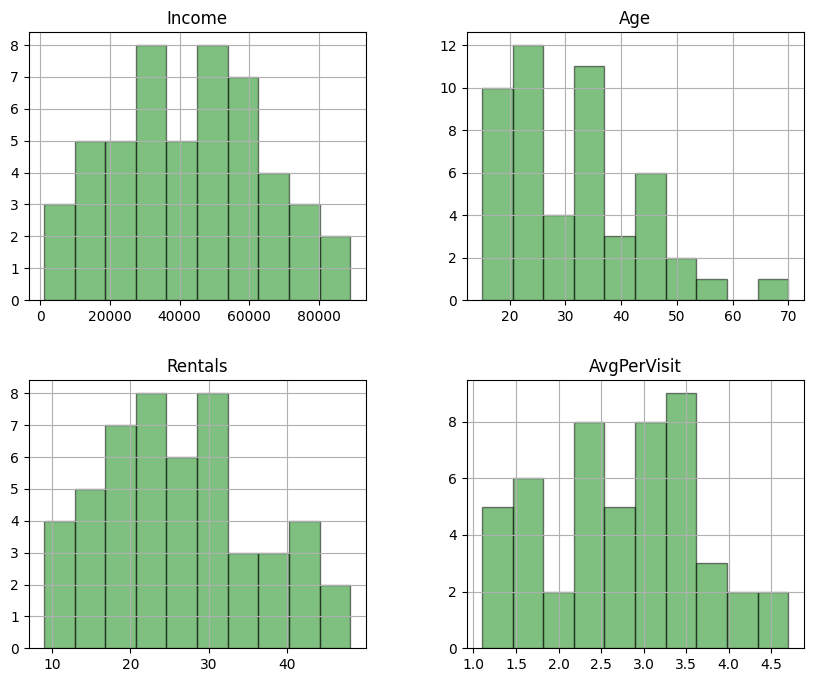

In [159]:
df = orginal_vtable
res = df[['Income', 'Age','Rentals','AvgPerVisit']]
res.hist(color='green',alpha=0.5, edgecolor = "black",figsize=(10, 8));


Like
1    26
0    24
Name: count, dtype: int64


<Axes: title={'center': 'Numbers in Like'}, xlabel='Like'>

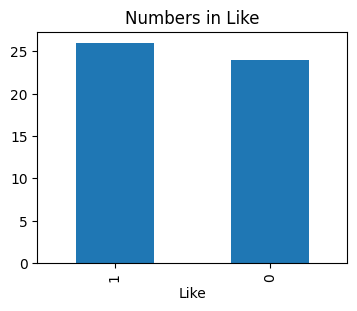

In [160]:
res = df['Like'].value_counts()
print(res)
res.plot( kind='bar',  title='Numbers in Like', figsize=(4, 3) )

# Step 3 : Data Processomg
### Convert categoric features to numerical feature


# Method 1 : Using LabelEncoder

#Step 4: KNN Classification

In [122]:
df = original_vtable
print(df.shape)
df.head(2)

(50, 8)


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No


In [123]:

# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features

#print('--------')
#df = orginal_vtable




from sklearn.preprocessing import LabelEncoder
# All category features are transfered as numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)
print(df.dtypes)
df.head(2)

# vs Method
le = LabelEncoder()
df = orginal_vtable
df['Gender'] = le.fit_transform(df['Gender'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Like'] = le.fit_transform(df['Like'])
df_use_LabelEncoder = df
print(df.dtypes)
df.head(2)

#There are problems!!!

Cust ID        int64
Gender         int64
Income         int64
Age            int64
Rentals        int64
AvgPerVisit    int64
Genre          int64
Like           int64
dtype: object
Cust ID          int64
Gender           int64
Income           int64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0


In [124]:
# vs Method
le = LabelEncoder()
df = original_vtable
df['Gender'] = le.fit_transform(df['Gender'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Like'] = le.fit_transform(df['Like'])
df_use_LabelEncoder = df
print(df.dtypes)
df.head(2)

Cust ID          int64
Gender           int64
Income           int64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0


In [125]:
#Only convert categorical features to Numerical features
le = LabelEncoder()
df = original_vtable
df['Gender'] = le.fit_transform(df['Gender'])
df['Genre'] = le.fit_transform(df['Genre'])
df['Like'] = le.fit_transform(df['Like'])
df_use_LabelEncoder = df
print(df.dtypes)
df.head(2)

Cust ID          int64
Gender           int64
Income           int64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0


In [126]:
# Current process data has not category
vtable_after_LabelEncoder = df
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(3, 6)
(3,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,1,45000.0,25,32,2.5,0
1,0,54000.0,33,12,3.4,2
2,0,32000.0,20,42,1.6,1


In [130]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
print(data_train)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(2, 6)
(1, 6)
(2,)
(1,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
   Gender   Income  Age  Rentals  AvgPerVisit  Genre
2       0  32000.0   20       42          1.6      1
1       0  54000.0   33       12          3.4      2


ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 3, n_samples_fit = 2, n_samples = 1

#Step 5: Converting categorical
#


##Method 2 : Using get_dummies -

In [165]:
original_vtable = pd.read_csv(video_store_file)
original_vtable.head(3)
df.head(2)


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0


In [166]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies
gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
#print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
v_matrix.head(2)

# Problem : numberical features also changed !!!!


   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1   45000   25       32          2.5      0     1
1        2       0   54000   33       12          3.4      2     0


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2,0,1
1,2,0,54000,33,12,3,2,0


In [167]:

# Only convert Converting categoric features to numerical feature
# Method 2 : Using get_dummies -
category_cols = ['Gender','Genre','Like']

df_use_dummies = pd.get_dummies(df, columns=category_cols, dtype=int)
print('--------')
print(df_use_dummies.dtypes)
df_use_dummies.head(2)




--------
Cust ID          int64
Income           int64
Age              int64
Rentals          int64
AvgPerVisit    float64
Gender_0         int64
Gender_1         int64
Genre_0          int64
Genre_1          int64
Genre_2          int64
Like_0           int64
Like_1           int64
dtype: object


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2,Like_0,Like_1
0,1,45000,25,32,2.5,0,1,1,0,0,0,1
1,2,54000,33,12,3.4,1,0,0,0,1,1,0


In [168]:
df_use_dummies.shape
df_use_dummies.head(2)


,Cust ID,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2,Like_0,Like_1
0,1,45000,25,32,2.5,0,1,1,0,0,0,1
1,2,54000,33,12,3.4,1,0,0,0,1,1,0


In [169]:
# Current process data has not category
vtable = df_use_dummies
# Seperate data part
v_data = vtable[['Income','Age','Rentals', 'AvgPerVisit','Gender_0','Gender_1',	'Genre_0'	,'Genre_1',	'Genre_2']]
# Get target
v_target = vtable['Like_0']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 9)
(50,)


,Income,Age,Rentals,AvgPerVisit,Gender_0,Gender_1,Genre_0,Genre_1,Genre_2
0,45000,25,32,2.5,0,1,1,0,0
1,54000,33,12,3.4,1,0,0,0,1
2,32000,20,42,1.6,1,0,0,1,0


#Step 6:KNN Classification Again

In [173]:
# Seperate data and target, after use dummies
all_cols = df_use_dummies.columns
print(df_use_dummies.head(2))
print(all_cols)

size = len(all_cols)
#print(size)

data_cols =all_cols [0:(size-2)]
#print(data_cols)
#print(df_use_dummies.columns[0:(size-2)] )

# Seperate data part
# v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
v_data = df_use_dummies[data_cols]
# Get target
v_target = df_use_dummies['Like_1']

print(v_data.shape)
print(v_target.shape)


   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_0  Gender_1  Genre_0  \
0        1   45000   25       32          2.5         0         1        1   
1        2   54000   33       12          3.4         1         0        0   

   Genre_1  Genre_2  Like_0  Like_1  
0        0        0       0       1  
1        0        1       1       0  
Index(['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_0',
       'Gender_1', 'Genre_0', 'Genre_1', 'Genre_2', 'Like_0', 'Like_1'],
      dtype='object')
(50, 10)
(50,)


In [175]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 8, test_size = .09)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(45, 10)
(5, 10)
(45,)
(5,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5

------ Confusion Matrix
[[2 0]
 [1 2]]


In [ ]:
v_data.head(2)

In [ ]:
v_target.head(2)

In [ ]:
data_train.describe()

In [ ]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

# Convert categoric feature to numerical feature

## Method 3 : Using HotOneEncoder


In [161]:

df = orginal_vtable
print(df.head(2))

#Income, Age, Rentals, AvgPerVisit (numeric)
# currently fails because KNN cannot convert strings like "M" to float .
# OneHotEncoder + MinMaxScaler

#from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline


# 1. Separate features and target
v_data = vtable[['Gender', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Genre']]
v_target = vtable['Like']
print(v_data.shape)
print(v_target.shape  )

# 2. Encode target Yes/No
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
y = label.fit_transform(v_target)
print(y)

# 3. Identify categorical and numeric columns
categorical_cols = ['Gender', 'Genre']
numeric_cols = ['Income', 'Age', 'Rentals', 'AvgPerVisit']

# # 4. Preprocessing: OneHot for categorical + MinMax scaling for numeric
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
encoded = ohe.fit_transform(df[['Gender']])
encoded_df = pd.DataFrame(encoded.toarray(), columns=ohe.get_feature_names_out(['Gender']))

# Convert to DataFrame (optional)
# import pandas as pd
#encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['sex']))

#df = pd.concat([df, encoded_df], axis=1)




   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1   45000   25       32          2.5      0     1
1        2       0   54000   33       12          3.4      2     0
(3, 6)
(3,)
[1 0 0]


In [162]:

from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', MinMaxScaler(), numeric_cols)
    ]
)

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['sex']])

# Convert to DataFrame (optional)
import pandas as pd
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['sex']))

df = pd.concat([df, encoded_df], axis=1)


# 5. Build KNN pipeline
model = Pipeline([
    ('prep', preprocess),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])

# 6. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

# 7. Fit model
model.fit(X_train, y_train)

# 8. Evaluate
print("Accuracy:", model.score(X_test, y_test))

NameError: name 'ColumnTransformer' is not defined

In [ ]:
print('Columns of v_train_norm:')
print(v_train_norm.columns)
print('\nDescriptive statistics of v_train_norm:')
display(v_train_norm.describe())

In [ ]:
# Method 1: Using

In [ ]:
print(v_train.shape)
print(v_test.shape)
print(target_train.shape)
print(target_test.shape)

In [ ]:
v_train.head(5)

In [ ]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler().fit(v_train)

v_train_norm = min_max_scaler.transform(v_train)
v_train_norm = pd.DataFrame(v_train_norm, columns = v_train.columns, index = v_train.index)
v_train_norm.head(5)

In [ ]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler().fit(v_test)

v_test_norm = min_max_scaler.transform(v_test)
v_test_norm = pd.DataFrame(v_test_norm, columns = v_test.columns, index = v_test.index)
v_test_norm.head(5)

# Lab 11 Classification - Anh


In [ ]:
# Create a KNN classifier

from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 5
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

In [ ]:
#Training
knn_classifier.fit (X = v_train_norm, y = target_train)
print(knn_classifier)

In [ ]:
#Testing
predicted = knn_classifier.predict(X= v_test_norm)

#What is size of predicted
predicted.shape

In [ ]:
predicted

In [ ]:
print(target_test)
target_test = list(target_test)
print(target_test)

In [ ]:
#Classifcation Evaluattion
#Percentage Accurarcy of the classification?
error_number = 0
for i in range(len(predicted)):
    if predicted[i] != target_test[i]:
        error_number += 1

print(error_number)
# Accuracy
accuracy_rate = 1 - error_number /len(predicted)
print('accuracy = ', format(accuracy_rate, '.4%'))

In [ ]:
#use scores method
score = knn_classifier.score(v_test_norm, target_test)
score

In [ ]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)